# Imports and load data

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:
df = pd.read_csv('../data/03_selected/selected_features_with_target.csv')

X = df.drop(columns=['target'])  

# Scale data

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dendrogram

Agglomerative approach with ward linkage

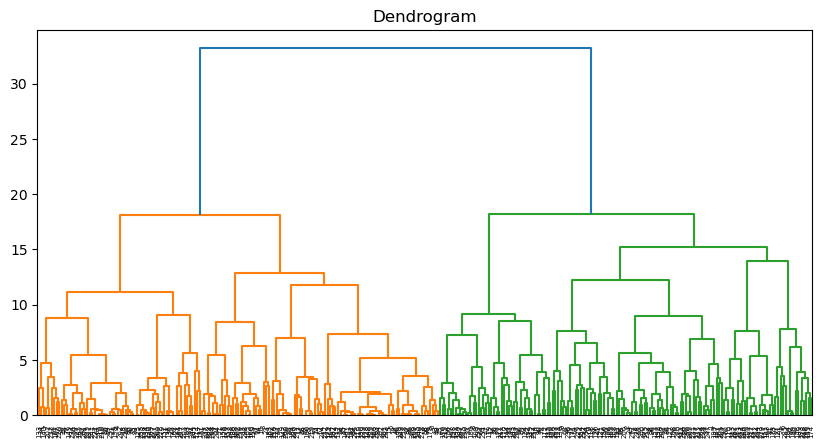

In [4]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()

# Decision: number of clusters

In [5]:
scores = []

for k in range(2, 10):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

print(scores)

[np.float64(0.2190098377343521), np.float64(0.16097757870301602), np.float64(0.1584009682472174), np.float64(0.17588578765797877), np.float64(0.18707240400779496), np.float64(0.1841789436762366), np.float64(0.19210112560060846), np.float64(0.20261901766790022)]


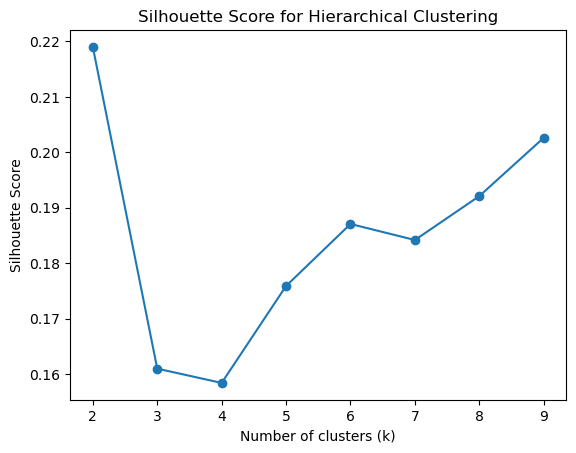

In [6]:
k_values = range(2, 10)

plt.plot(k_values, scores, marker='o')
plt.title("Silhouette Score for Hierarchical Clustering")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

The silhouette scores are relatively low (<0.5), suggesting that the cluster structure is not strongly defined. However, k=2 provides the best separation among the tested values.

# Apply clustering

In [7]:
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(X_scaled)

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

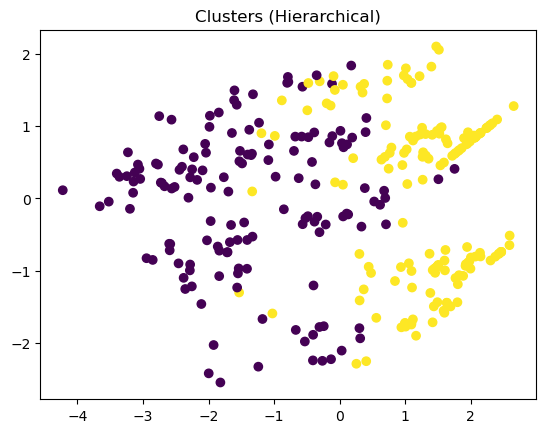

In [9]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Clusters (Hierarchical)")
plt.show()

In [10]:
df_clusters = pd.DataFrame(X)
df_clusters['cluster'] = labels

cluster_means = df_clusters.groupby('cluster').mean()
print(cluster_means)

            thalach   oldpeak        ca     sex_1      cp_4   exang_1  \
cluster                                                                 
0        138.390411  1.632877  0.938356  0.801370  0.732877  0.616438   
1        160.038217  0.487898  0.407643  0.566879  0.235669  0.057325   

          slope_2  thal_7.0  
cluster                      
0        0.801370  0.595890  
1        0.146497  0.191083  


In [11]:
y_true = df['target']

# Confusion matrix

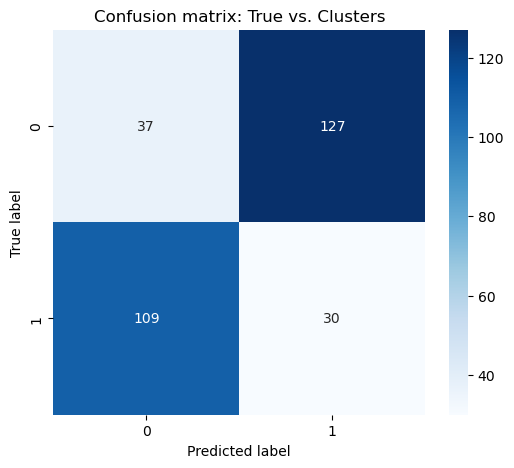

In [12]:
cm = confusion_matrix(y_true, labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix: True vs. Clusters")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# ARI score

In [13]:
ari = adjusted_rand_score(y_true, labels)
print(f"El ARI score es: {ari:.4f}")

El ARI score es: 0.3088
